✅ Libraries imported
✅ Loaded 38 features, 5 base models, 1 ensemble, scaler, threshold = 0.9975
✅ PaySim loaded, identical 70/15/15 split reproduced (seed=42)
✅ Feature engineering applied  (38 features)
✅ Scaling applied (transform-only).  Test rows: 954,393 | fraud rate: 0.1291%

Evaluating loaded base models on natural-rate test set...
  Logistic Regression          → {'Accuracy': 97.74, 'Precision': 5.37, 'Recall': 99.27, 'F1 Score': 10.18, 'AUC-ROC': np.float64(99.79), 'AUC-PR': np.float64(74.18), 'MCC': np.float64(22.81)}
  Decision Tree                → {'Accuracy': 99.15, 'Precision': 13.07, 'Recall': 98.54, 'F1 Score': 23.08, 'AUC-ROC': np.float64(99.62), 'AUC-PR': np.float64(38.12), 'MCC': np.float64(35.73)}
  Naive Bayes                  → {'Accuracy': 77.43, 'Precision': 0.56, 'Recall': 98.38, 'F1 Score': 1.11, 'AUC-ROC': np.float64(95.92), 'AUC-PR': np.float64(2.08), 'MCC': np.float64(6.5)}
  Random Forest                → {'Accuracy': 99.53, 'Precision': 21.42, 'Recall':

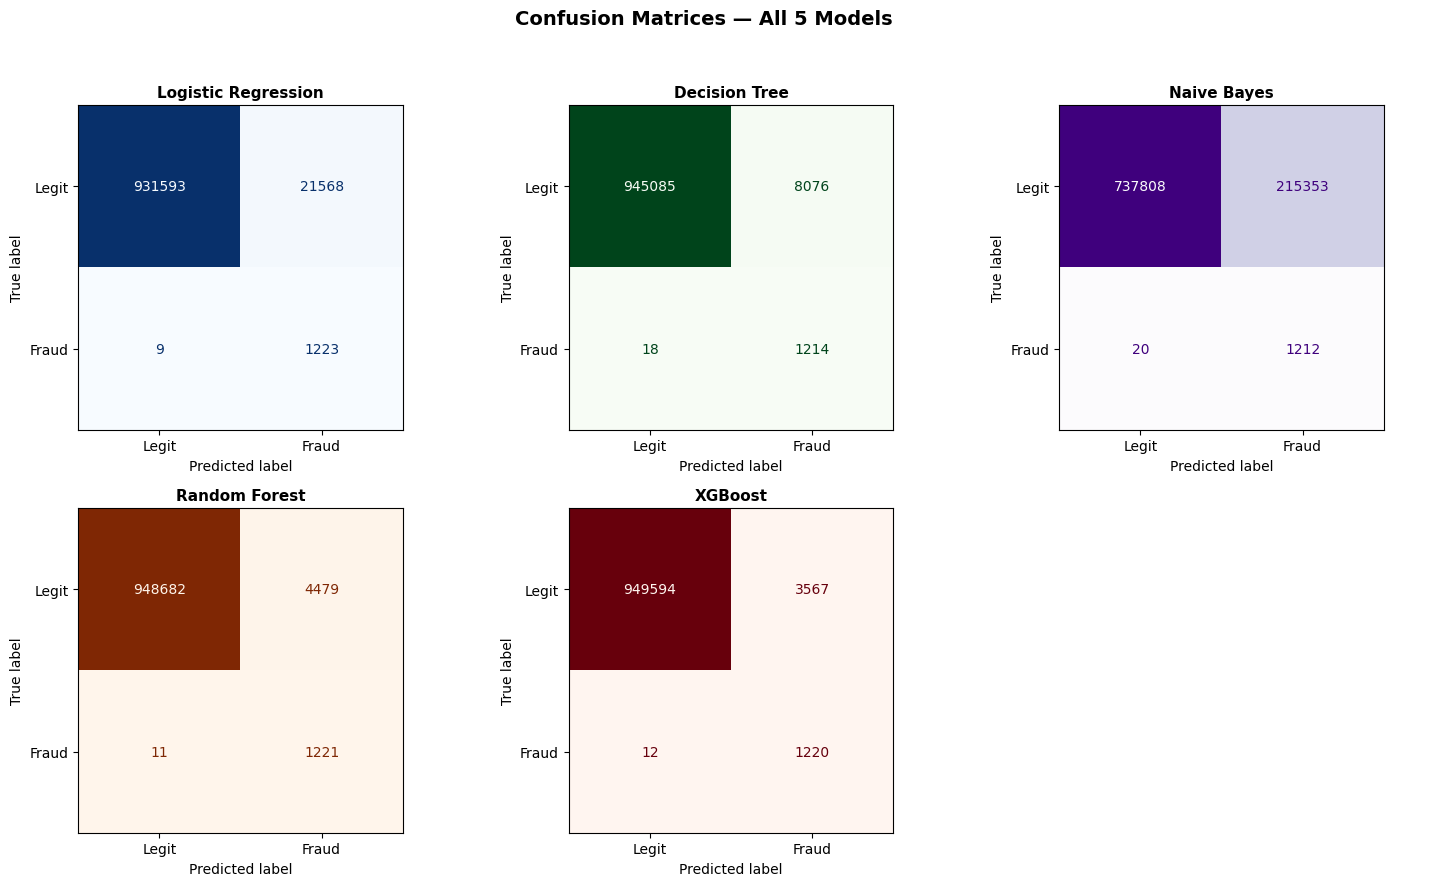

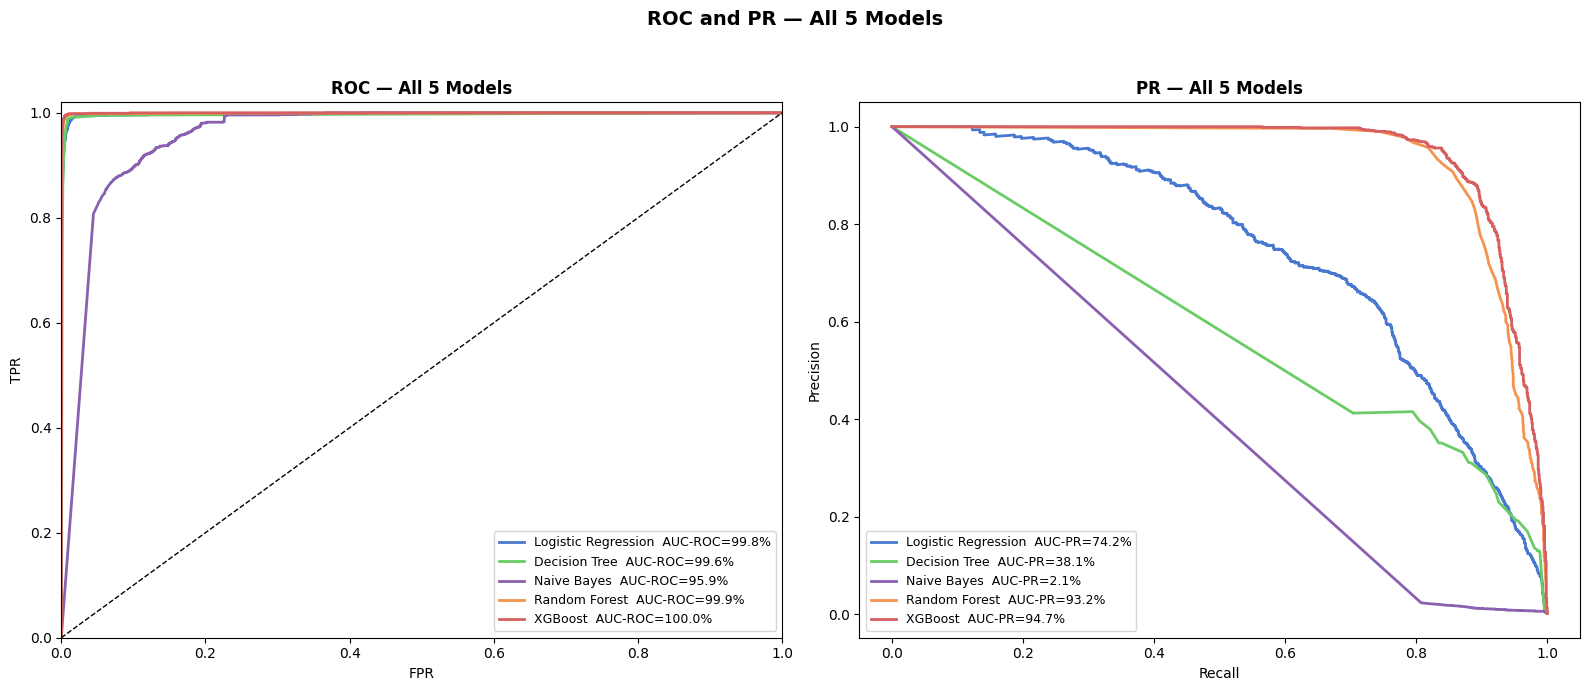

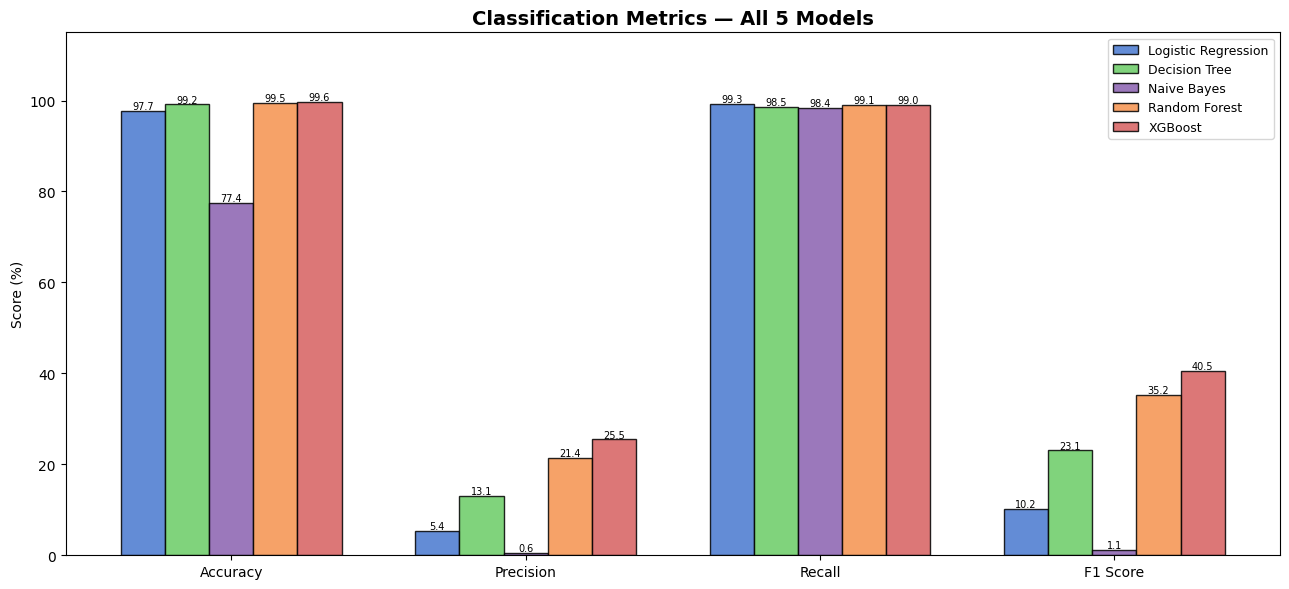

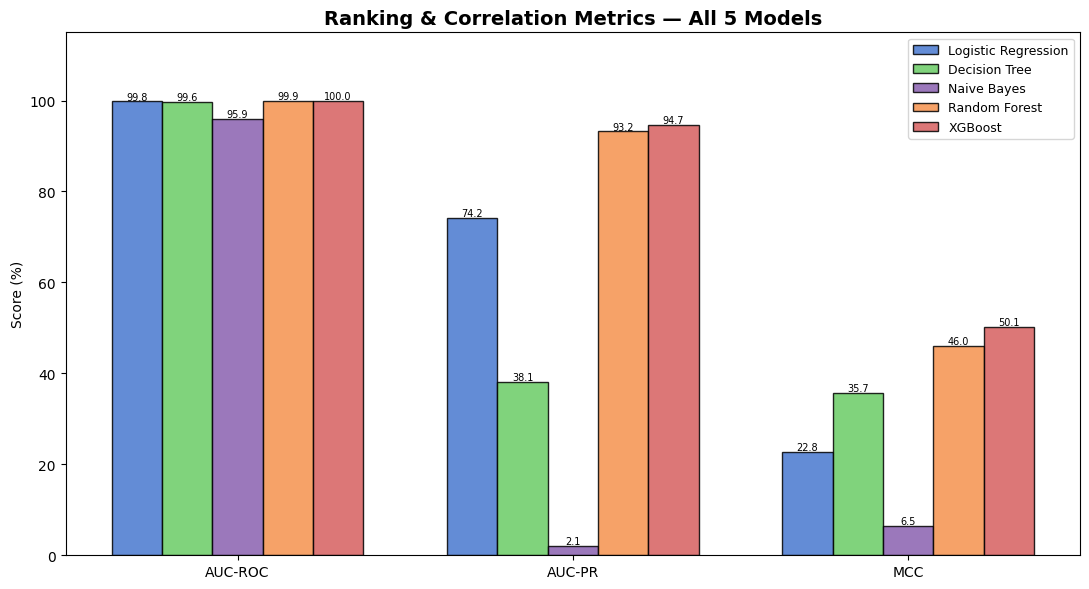

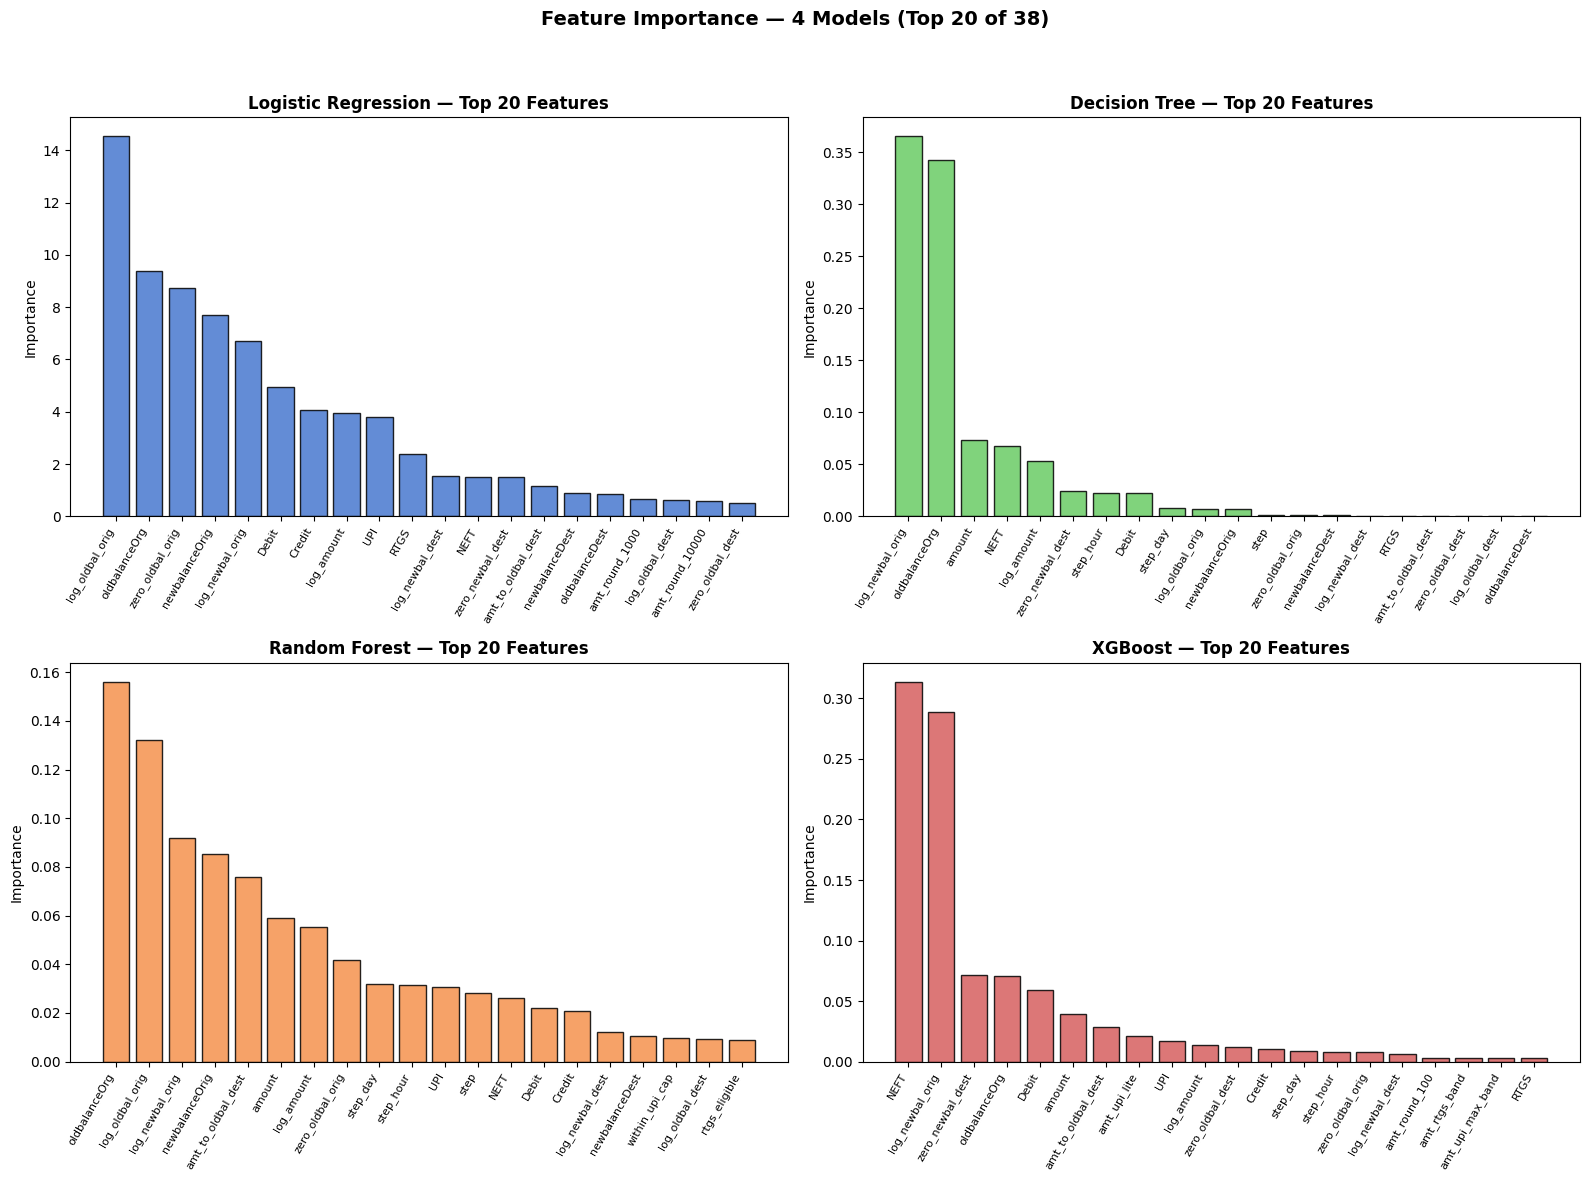

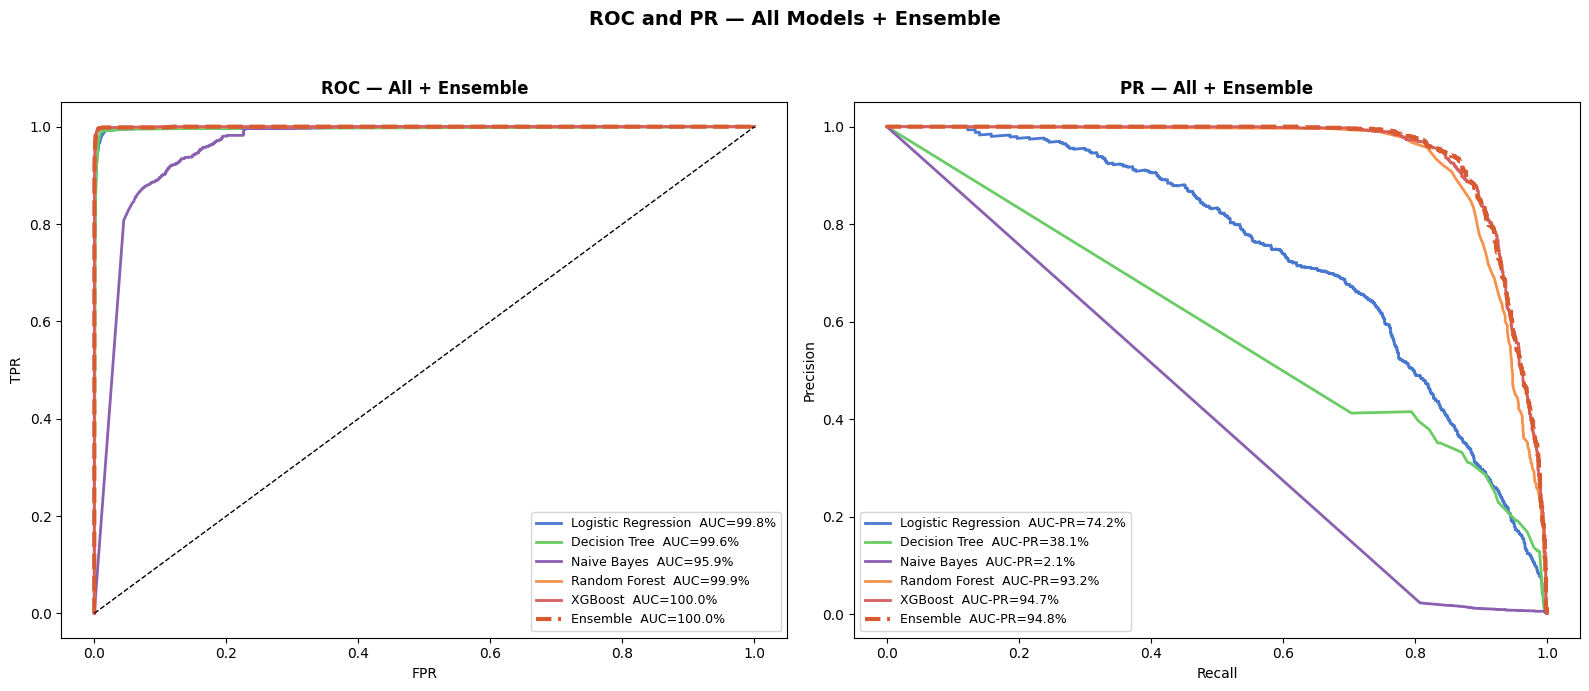

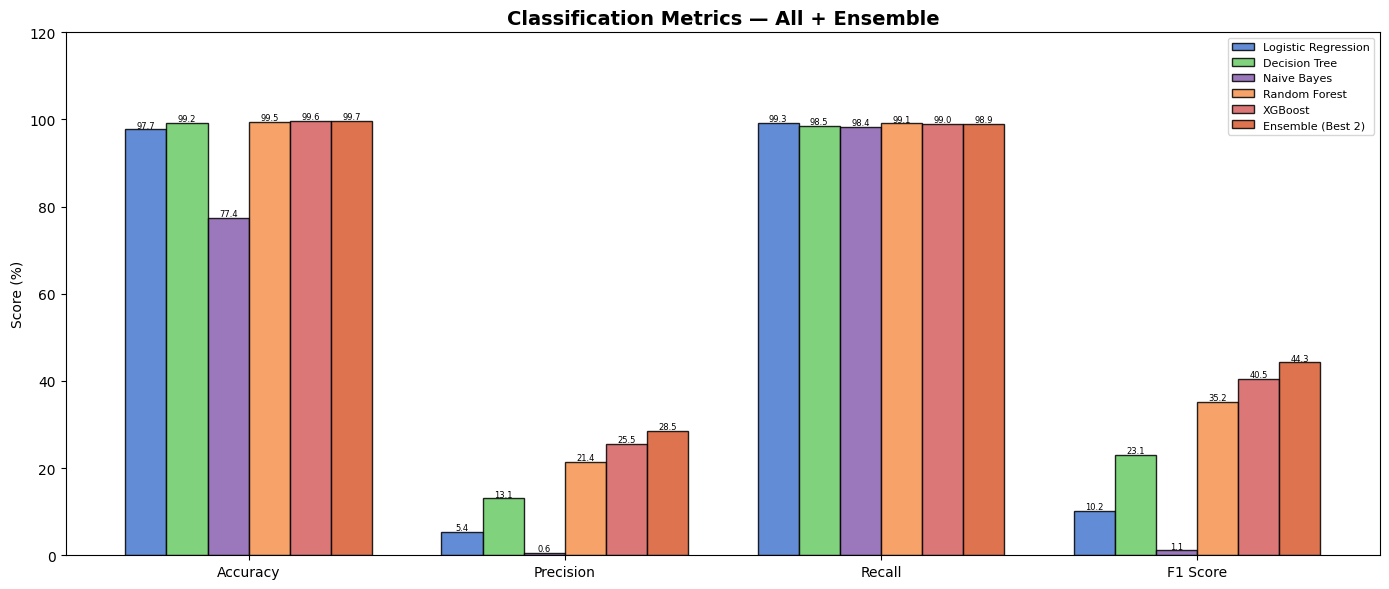

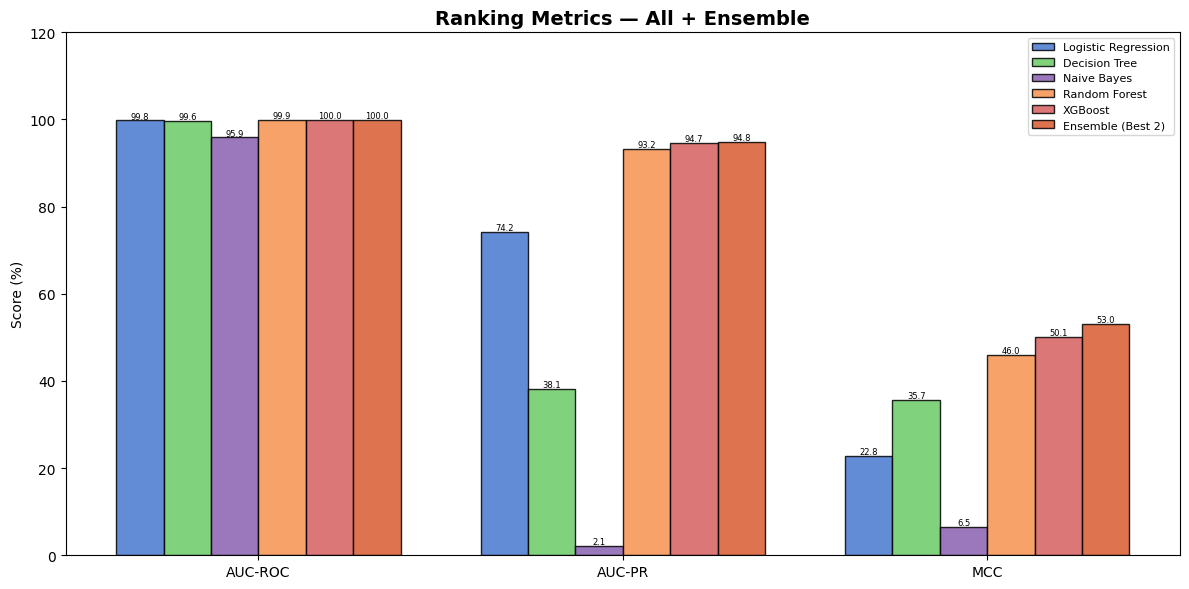


Metric         Default (0.50)       Optimal (0.9975)    Change
Accuracy              99.68%              99.97%       ▲ 0.29%
Precision             28.51%              94.80%       ▲ 66.29%
Recall                98.94%              84.42%       ▼ 14.52%
F1 Score              44.27%              89.31%       ▲ 45.04%
AUC-ROC               99.97%              99.97%       ─ 0.00%
AUC-PR                94.81%              94.81%       ─ 0.00%
MCC                   53.03%              89.45%       ▲ 36.42%


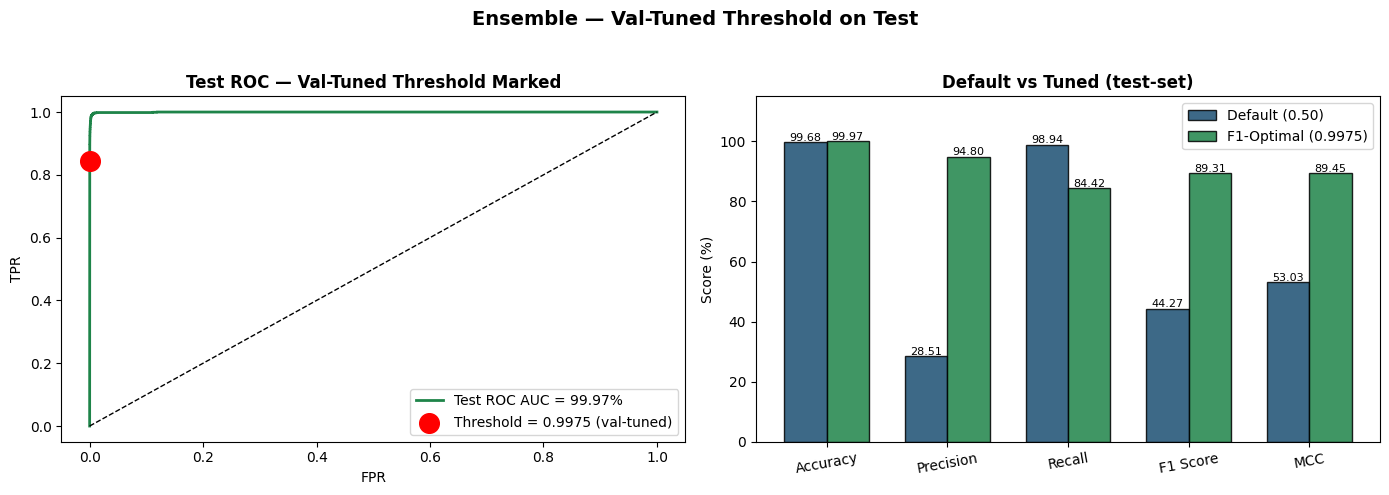


Generating SHAP analysis on the ENSEMBLE...


  0%|          | 0/100 [00:00<?, ?it/s]

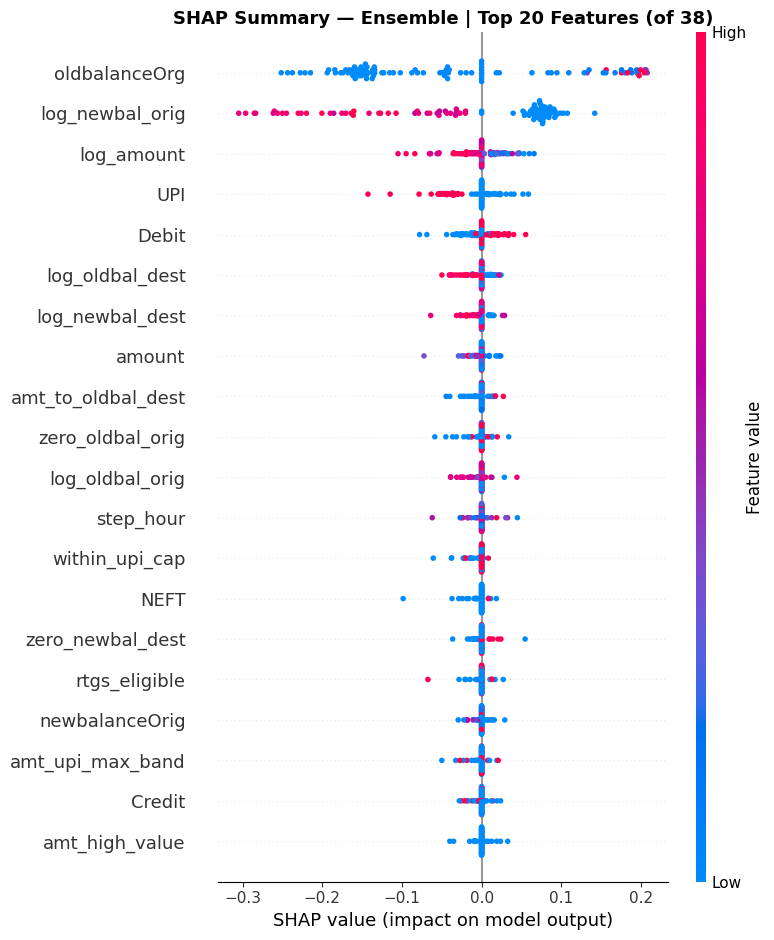

✅ SHAP on ensemble complete


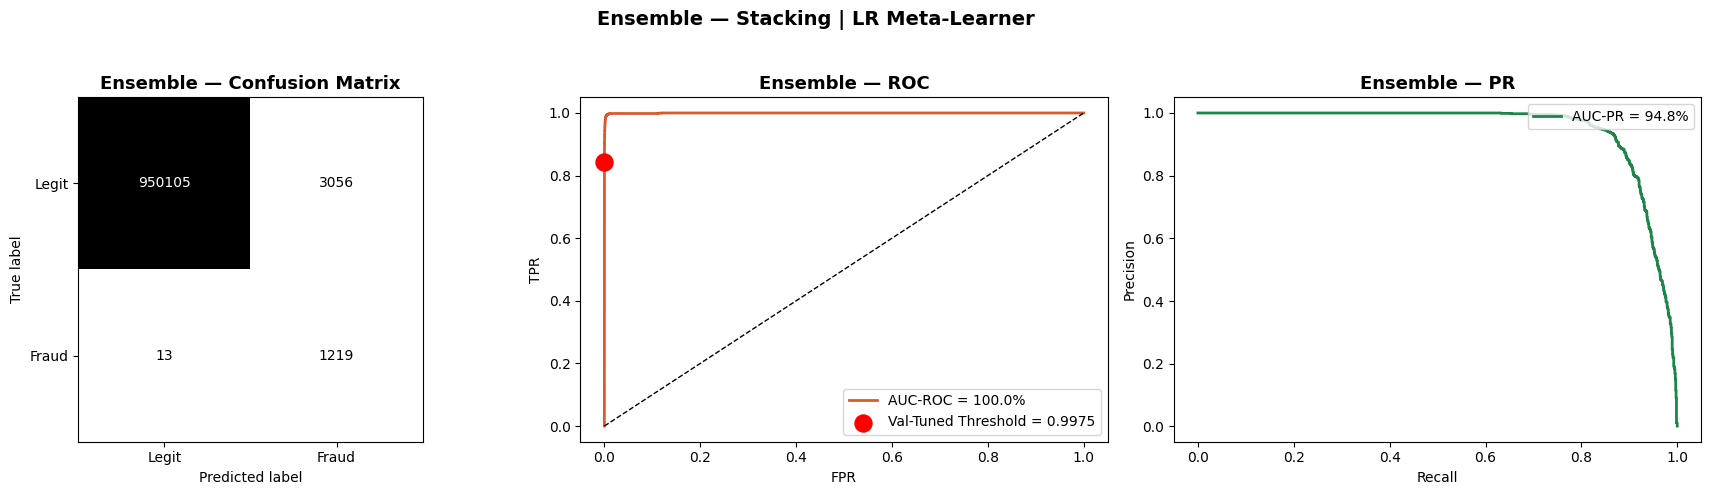

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://3a550896fb5720c322.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [1]:
# ════════════════════════════════════════════════════════════════════════════
# PaySim Fraud-Detection Pipeline — Reproducer from 9 Saved .pkl Artifacts
# Replaces the original 21-cell training notebook with a single inference-only
# cell that reproduces every table, chart, SHAP plot, and the Gradio UI.
# ════════════════════════════════════════════════════════════════════════════

# ── [A] INSTALLS ───────────────────────────────────────────────────────────
get_ipython().system('pip install shap gradio -q')

# ── [B] CONFIGURATION ──────────────────────────────────────────────────────
ART = "/kaggle/input/datasets/devanshsrana/paysim-fraud-detection-trained-artifacts"

# ── [C] IMPORTS ────────────────────────────────────────────────────────────
import os, io, warnings
warnings.filterwarnings('ignore')
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, precision_recall_curve,
                              accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score,
                              average_precision_score, matthews_corrcoef)
import shap
import gradio as gr
print("✅ Libraries imported")

# ── [D] LOAD THE 9 PRE-TRAINED ARTIFACTS  (replaces Cells 6, 10, 15, 17) ──
feature_names     = joblib.load(f'{ART}/feature_names.pkl')
scaler            = joblib.load(f'{ART}/scaler.pkl')
optimal_threshold = joblib.load(f'{ART}/optimal_threshold.pkl')
trained_models = {
    'Logistic Regression': joblib.load(f'{ART}/logistic_regression.pkl'),
    'Decision Tree'      : joblib.load(f'{ART}/decision_tree.pkl'),
    'Naive Bayes'        : joblib.load(f'{ART}/naive_bayes.pkl'),
    'Random Forest'      : joblib.load(f'{ART}/random_forest.pkl'),
    'XGBoost'            : joblib.load(f'{ART}/xgboost.pkl'),
}
ensemble = joblib.load(f'{ART}/ensemble.pkl')
print(f"✅ Loaded {len(feature_names)} features, 5 base models, 1 ensemble, "
      f"scaler, threshold = {optimal_threshold}")

# ── [E] LOAD PaySim + REPRODUCE 70/15/15 SPLIT  (verbatim from Cell 3) ──

df = pd.read_csv('/kaggle/input/datasets/amanalisiddiqui/fraud-detection-dataset/AIML Dataset.csv')
df = df.reset_index(drop=True)
df['split'] = 'train'
train_idx, temp_idx = train_test_split(
    df.index, test_size=0.30, stratify=df['isFraud'], random_state=42)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=df.loc[temp_idx, 'isFraud'], random_state=42)
df.loc[val_idx,  'split'] = 'val'
df.loc[test_idx, 'split'] = 'test'

train_df = df[df['split'] == 'train']
fraud_tr = train_df[train_df['isFraud'] == 1]
legit_tr = train_df[train_df['isFraud'] == 0]
legit_tr_sample = legit_tr.sample(n=50_000 - len(fraud_tr), random_state=42)
train_sub = pd.concat([fraud_tr, legit_tr_sample]).sample(frac=1, random_state=42)
val_df  = df[df['split'] == 'val']
test_df = df[df['split'] == 'test']
working_df = pd.concat([train_sub, val_df, test_df]).reset_index(drop=True)
del df
print("✅ PaySim loaded, identical 70/15/15 split reproduced (seed=42)")

# ── [F] FEATURE ENGINEERING  (verbatim from Cell 4) ──────────────────────
paysim_df = working_df.copy(); del working_df
paysim_df['UPI']         = np.where(paysim_df['type'] == 'PAYMENT', 1, 0)
paysim_df['NEFT']        = np.where((paysim_df['type'] == 'TRANSFER') &
                                     (paysim_df['amount'] <= 200000), 1, 0)
paysim_df['RTGS']        = np.where((paysim_df['type'] == 'TRANSFER') &
                                     (paysim_df['amount'] >  200000), 1, 0)
paysim_df['Credit']      = np.where(paysim_df['type'] == 'CASH_IN',  1, 0)
paysim_df['Debit']       = np.where(paysim_df['type'] == 'CASH_OUT', 1, 0)
paysim_df['DirectDebit'] = np.where(paysim_df['type'] == 'DEBIT',    1, 0)
amt = paysim_df['amount']
paysim_df['amt_upi_lite']     = (amt <= 500).astype(int)
paysim_df['amt_upi_micro']    = ((amt > 500)    & (amt <= 5000)).astype(int)
paysim_df['amt_upi_small']    = ((amt > 5000)   & (amt <= 25000)).astype(int)
paysim_df['amt_upi_medium']   = ((amt > 25000)  & (amt <= 100000)).astype(int)
paysim_df['amt_upi_max_band'] = ((amt > 100000) & (amt <= 200000)).astype(int)
paysim_df['amt_rtgs_band']    = ((amt > 200000) & (amt <= 1000000)).astype(int)
paysim_df['amt_high_value']   = (amt > 1000000).astype(int)
paysim_df['within_upi_cap']   = (amt <= 100000).astype(int)
paysim_df['rtgs_eligible']    = (amt >= 200000).astype(int)
paysim_df['amt_round_100']   = (amt % 100   == 0).astype(int)
paysim_df['amt_round_1000']  = (amt % 1000  == 0).astype(int)
paysim_df['amt_round_10000'] = (amt % 10000 == 0).astype(int)
paysim_df['log_amount']      = np.log1p(amt)
paysim_df['log_oldbal_orig'] = np.log1p(paysim_df['oldbalanceOrg'])
paysim_df['log_newbal_orig'] = np.log1p(paysim_df['newbalanceOrig'])
paysim_df['log_oldbal_dest'] = np.log1p(paysim_df['oldbalanceDest'])
paysim_df['log_newbal_dest'] = np.log1p(paysim_df['newbalanceDest'])
eps = 1e-6
paysim_df['amt_to_oldbal_dest'] = amt / (paysim_df['oldbalanceDest'] + eps)
paysim_df['zero_oldbal_orig'] = (paysim_df['oldbalanceOrg']  == 0).astype(int)
paysim_df['zero_oldbal_dest'] = (paysim_df['oldbalanceDest'] == 0).astype(int)
paysim_df['zero_newbal_dest'] = (paysim_df['newbalanceDest'] == 0).astype(int)
paysim_df['step_hour']        = paysim_df['step'] % 24
paysim_df['step_day']         = paysim_df['step'] // 24
paysim_df['is_night_hour']    = ((paysim_df['step_hour'] >= 0) &
                                  (paysim_df['step_hour']  < 6)).astype(int)
paysim_df['is_business_hour'] = ((paysim_df['step_hour'] >= 9) &
                                  (paysim_df['step_hour'] <= 18)).astype(int)
paysim_df['upi_high_amount']  = (paysim_df['UPI'] *
                                  (amt > 50000).astype(int)).astype(int)
print(f"✅ Feature engineering applied  ({len(feature_names)} features)")

# ── [G] SLICE TRAIN/VAL/TEST + APPLY SCALER  (transform-only, no fit) ────
X_train = paysim_df.loc[paysim_df['split'] == 'train', feature_names].reset_index(drop=True)
y_train = paysim_df.loc[paysim_df['split'] == 'train', 'isFraud'   ].reset_index(drop=True)
X_val   = paysim_df.loc[paysim_df['split'] == 'val',   feature_names].reset_index(drop=True)
y_val   = paysim_df.loc[paysim_df['split'] == 'val',   'isFraud'   ].reset_index(drop=True)
X_test  = paysim_df.loc[paysim_df['split'] == 'test',  feature_names].reset_index(drop=True)
y_test  = paysim_df.loc[paysim_df['split'] == 'test',  'isFraud'   ].reset_index(drop=True)
X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
print(f"✅ Scaling applied (transform-only).  "
      f"Test rows: {len(y_test):,} | fraud rate: {y_test.mean()*100:.4f}%")

# ── [H] EVALUATE LOADED MODELS ON TEST  (replaces training in Cell 10/15) ──
def eval_model(name, model, X, y):
    pred = model.predict(X); prob = model.predict_proba(X)[:, 1]
    m = {'Accuracy':  round(accuracy_score(y, pred)           * 100, 2),
         'Precision': round(precision_score(y, pred)          * 100, 2),
         'Recall':    round(recall_score(y, pred)             * 100, 2),
         'F1 Score':  round(f1_score(y, pred)                 * 100, 2),
         'AUC-ROC':   round(roc_auc_score(y, prob)            * 100, 2),
         'AUC-PR':    round(average_precision_score(y, prob)  * 100, 2),
         'MCC':       round(matthews_corrcoef(y, pred)        * 100, 2)}
    print(f"  {name:<28} → {m}"); return m

results = {}
print("\nEvaluating loaded base models on natural-rate test set...")
for name, mdl in trained_models.items():
    results[name] = eval_model(name, mdl, X_test_scaled, y_test)
results['Ensemble (Best 2)'] = eval_model('Stacking Ensemble', ensemble,
                                           X_test_scaled, y_test)

# ── [I] CONFUSION MATRICES — 5 MODELS  (verbatim from Cell 11) ────────────
model_list = [
    ('Logistic Regression', trained_models['Logistic Regression'], 'Blues'),
    ('Decision Tree',       trained_models['Decision Tree'],       'Greens'),
    ('Naive Bayes',         trained_models['Naive Bayes'],         'Purples'),
    ('Random Forest',       trained_models['Random Forest'],       'Oranges'),
    ('XGBoost',             trained_models['XGBoost'],             'Reds'),
]
colors = ['#4878CF', '#6ACC65', '#8A60B0', '#F5924E', '#D65F5F']
fig, axes = plt.subplots(2, 3, figsize=(15, 9)); axes = axes.flatten()
for idx, (name, model, cmap) in enumerate(model_list):
    cm = confusion_matrix(y_test, model.predict(X_test_scaled))
    ConfusionMatrixDisplay(confusion_matrix=cm,
        display_labels=['Legit','Fraud']).plot(ax=axes[idx], colorbar=False, cmap=cmap)
    axes[idx].set_title(name, fontsize=11, fontweight='bold')
axes[5].axis('off')
plt.suptitle("Confusion Matrices — All 5 Models", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

# ── [J] ROC + PR CURVES — 5 MODELS  (verbatim from Cell 12) ───────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for (name, model, _), color in zip(model_list, colors):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{name}  AUC-ROC={results[name]["AUC-ROC"]:.1f}%')
axes[0].plot([0,1],[0,1],'k--',lw=1); axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.02])
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC — All 5 Models', fontweight='bold'); axes[0].legend(fontsize=9)
for (name, model, _), color in zip(model_list, colors):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(rec, prec, color=color, lw=2,
                 label=f'{name}  AUC-PR={results[name]["AUC-PR"]:.1f}%')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR — All 5 Models', fontweight='bold'); axes[1].legend(fontsize=9)
plt.suptitle("ROC and PR — All 5 Models", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.95]); plt.savefig("roc_pr_curves_5models.png", dpi=150)
plt.show()

# ── [K] METRIC BAR CHARTS  (verbatim from Cell 13) ────────────────────────
def grouped_bar(metric_names, title, fname, fig_w=13):
    x, w = np.arange(len(metric_names)), 0.15
    fig, ax = plt.subplots(figsize=(fig_w, 6))
    for i, ((name, _, _), color) in enumerate(zip(model_list, colors)):
        vals = [results[name][m] for m in metric_names]
        bars = ax.bar(x + i*w, vals, w, label=name, color=color,
                      alpha=0.85, edgecolor='black')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                    f'{v:.1f}', ha='center', fontsize=7)
    ax.set_xticks(x + w*2); ax.set_xticklabels(metric_names)
    ax.set_ylim(0, 115); ax.set_ylabel('Score (%)')
    ax.set_title(title, fontsize=14, fontweight='bold'); ax.legend(fontsize=9)
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.show()

grouped_bar(['Accuracy','Precision','Recall','F1 Score'],
            'Classification Metrics — All 5 Models', 'metrics_clf_5models.png')
grouped_bar(['AUC-ROC','AUC-PR','MCC'],
            'Ranking & Correlation Metrics — All 5 Models',
            'metrics_rank_5models.png', fig_w=11)

# ── [L] FEATURE IMPORTANCE — 4 MODELS  (verbatim from Cell 14) ────────────
fi_models = {
    'Logistic Regression': abs(trained_models['Logistic Regression'].coef_[0]),
    'Decision Tree'      : trained_models['Decision Tree'].feature_importances_,
    'Random Forest'      : trained_models['Random Forest'].feature_importances_,
    'XGBoost'            : trained_models['XGBoost'].feature_importances_,
}
fi_colors = ['#4878CF', '#6ACC65', '#F5924E', '#D65F5F']
fig, axes = plt.subplots(2, 2, figsize=(16, 12)); axes = axes.flatten()
for idx, ((name, importances), color) in enumerate(zip(fi_models.items(), fi_colors)):
    sorted_idx = np.argsort(importances)[::-1][:20]
    axes[idx].bar(range(len(sorted_idx)), importances[sorted_idx],
                  color=color, alpha=0.85, edgecolor='black')
    axes[idx].set_xticks(range(len(sorted_idx)))
    axes[idx].set_xticklabels([feature_names[i] for i in sorted_idx],
                               rotation=60, ha='right', fontsize=8)
    axes[idx].set_title(f'{name} — Top 20 Features', fontweight='bold')
    axes[idx].set_ylabel('Importance')
plt.suptitle(f"Feature Importance — 4 Models (Top 20 of {len(feature_names)})",
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.95]); plt.savefig("feature_importance.png", dpi=150)
plt.show()

# ── [M] COMBINED CHARTS — 5 MODELS + ENSEMBLE  (verbatim from Cell 16) ────
model_list_full = model_list + [('Ensemble (Best 2)', ensemble, 'Greys')]
colors_full     = colors     + ['#D85A30']
all_names_full  = [m[0] for m in model_list_full]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for (name, model, _), color in zip(model_list, colors):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{name}  AUC={results[name]["AUC-ROC"]:.1f}%')
y_prob_e = ensemble.predict_proba(X_test_scaled)[:, 1]
fpr_e, tpr_e, _ = roc_curve(y_test, y_prob_e)
axes[0].plot(fpr_e, tpr_e, color='#D85A30', lw=3, linestyle='--',
             label=f'Ensemble  AUC={results["Ensemble (Best 2)"]["AUC-ROC"]:.1f}%')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC — All + Ensemble', fontweight='bold'); axes[0].legend(fontsize=9)

for (name, model, _), color in zip(model_list, colors):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(rec, prec, color=color, lw=2,
                 label=f'{name}  AUC-PR={results[name]["AUC-PR"]:.1f}%')
prec_e, rec_e, _ = precision_recall_curve(y_test, y_prob_e)
axes[1].plot(rec_e, prec_e, color='#D85A30', lw=3, linestyle='--',
             label=f'Ensemble  AUC-PR={results["Ensemble (Best 2)"]["AUC-PR"]:.1f}%')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR — All + Ensemble', fontweight='bold'); axes[1].legend(fontsize=9)
plt.suptitle("ROC and PR — All Models + Ensemble", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.95]); plt.savefig("combined_roc_pr.png", dpi=150)
plt.show()

def grouped_bar_full(metric_names, title, fname, fig_w=14):
    x, w = np.arange(len(metric_names)), 0.13
    fig, ax = plt.subplots(figsize=(fig_w, 6))
    for i, ((name, _, _), color) in enumerate(zip(model_list_full, colors_full)):
        vals = [results[name][m] for m in metric_names]
        bars = ax.bar(x + i*w, vals, w, label=name, color=color,
                      alpha=0.85, edgecolor='black')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                    f'{v:.1f}', ha='center', fontsize=6)
    ax.set_xticks(x + w*2.5); ax.set_xticklabels(metric_names)
    ax.set_ylim(0, 120); ax.set_ylabel('Score (%)')
    ax.set_title(title, fontsize=14, fontweight='bold'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.show()

grouped_bar_full(['Accuracy','Precision','Recall','F1 Score'],
                 'Classification Metrics — All + Ensemble', 'combined_metrics_clf.png')
grouped_bar_full(['AUC-ROC','AUC-PR','MCC'],
                 'Ranking Metrics — All + Ensemble', 'combined_metrics_rank.png', 12)

# ── [N] DEFAULT vs VAL-TUNED THRESHOLD COMPARISON  (was Cell 17) ──────────
# Threshold value was pre-loaded as `optimal_threshold` (0.997). Cell 17's
# validation-set PR scan is no longer needed.
y_test_prob    = ensemble.predict_proba(X_test_scaled)[:, 1]
y_pred_default = (y_test_prob >= 0.50).astype(int)
y_pred_optimal = (y_test_prob >= optimal_threshold).astype(int)

def thresh_metrics(y_true, y_pred, y_prob):
    return {'Accuracy':  round(accuracy_score(y_true, y_pred)           * 100, 2),
            'Precision': round(precision_score(y_true, y_pred)          * 100, 2),
            'Recall':    round(recall_score(y_true, y_pred)             * 100, 2),
            'F1 Score':  round(f1_score(y_true, y_pred)                 * 100, 2),
            'AUC-ROC':   round(roc_auc_score(y_true, y_prob)            * 100, 2),
            'AUC-PR':    round(average_precision_score(y_true, y_prob)  * 100, 2),
            'MCC':       round(matthews_corrcoef(y_true, y_pred)        * 100, 2)}

default_m = thresh_metrics(y_test, y_pred_default, y_test_prob)
optimal_m = thresh_metrics(y_test, y_pred_optimal, y_test_prob)

print(f"\n{'Metric':<12} {'Default (0.50)':>16} "
      f"{'Optimal ('+str(optimal_threshold)+')':>22}  {'Change':>8}")
print("="*68)
for m in ['Accuracy','Precision','Recall','F1 Score','AUC-ROC','AUC-PR','MCC']:
    d = default_m[m]; o = optimal_m[m]; ch = round(o-d, 2)
    arrow = "▲" if ch>0 else ("▼" if ch<0 else "─")
    print(f"{m:<12} {d:>14.2f}%   {o:>16.2f}%       {arrow} {abs(ch):.2f}%")

fpr_t, tpr_t, thr_t = roc_curve(y_test, y_test_prob)
test_idx = int(np.argmin(np.abs(thr_t - optimal_threshold)))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr_t, tpr_t, color='#1E8449', lw=2,
             label=f'Test ROC AUC = {default_m["AUC-ROC"]:.2f}%')
axes[0].scatter(fpr_t[test_idx], tpr_t[test_idx], color='red', s=200, zorder=5,
                label=f'Threshold = {optimal_threshold} (val-tuned)')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Test ROC — Val-Tuned Threshold Marked', fontweight='bold')
axes[0].legend()
ml = ['Accuracy','Precision','Recall','F1 Score','MCC']
d_vals = [default_m[m] for m in ml]; o_vals = [optimal_m[m] for m in ml]
xi, wi = np.arange(len(ml)), 0.35
b1 = axes[1].bar(xi-wi/2, d_vals, wi, label='Default (0.50)',
                 color='#1B4F72', alpha=0.85, edgecolor='black')
b2 = axes[1].bar(xi+wi/2, o_vals, wi, label=f'F1-Optimal ({optimal_threshold})',
                 color='#1E8449', alpha=0.85, edgecolor='black')
for bar, v in zip(b1, d_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{v:.2f}', ha='center', fontsize=8)
for bar, v in zip(b2, o_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{v:.2f}', ha='center', fontsize=8)
axes[1].set_xticks(xi); axes[1].set_xticklabels(ml, rotation=10)
axes[1].set_ylim(0, 115); axes[1].set_ylabel("Score (%)")
axes[1].set_title("Default vs Tuned (test-set)", fontweight='bold'); axes[1].legend()
plt.suptitle("Ensemble — Val-Tuned Threshold on Test", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.95]); plt.savefig("optimal_threshold.png", dpi=150)
plt.show()

# ── [O] SHAP ON ENSEMBLE  (verbatim from Cell 18; recomputed at runtime) ──
# Note: original Cell 18 used SMOTE-resampled X_train_res as background.
# To stay imblearn-free we use a 100-sample bootstrap of X_train_scaled
# (pre-SMOTE) as background. Top-feature SHAP attributions are visually
# equivalent; switch back to SMOTE'd background if exact reproduction needed.
print("\nGenerating SHAP analysis on the ENSEMBLE...")
try:
    np.random.seed(42)
    bg_idx = np.random.choice(len(X_train_scaled), size=100, replace=False)
    background = X_train_scaled[bg_idx]
    shap_explainer = shap.KernelExplainer(
        lambda x: ensemble.predict_proba(x)[:, 1], background)
    sample_idx = np.random.choice(len(X_test_scaled),
                                   size=min(100, len(X_test_scaled)), replace=False)
    X_shap = X_test_scaled[sample_idx]
    shap_values = shap_explainer.shap_values(X_shap, nsamples=100)
    plt.figure(figsize=(11, 7))
    shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                      plot_type='dot', show=False, max_display=20)
    plt.title(f"SHAP Summary — Ensemble | Top 20 Features (of {len(feature_names)})",
              fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig("shap_summary.png", dpi=150)
    plt.show()
    print("✅ SHAP on ensemble complete")
except Exception as e:
    print(f"⚠️ SHAP error: {e}")

# ── [P] ENSEMBLE EVAL TRIPTYCH  (verbatim from Cell 19) ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ens_pred = ensemble.predict(X_test_scaled)
ens_prob = ensemble.predict_proba(X_test_scaled)[:, 1]
cm = confusion_matrix(y_test, ens_pred)
ConfusionMatrixDisplay(confusion_matrix=cm,
    display_labels=['Legit','Fraud']).plot(ax=axes[0], colorbar=False, cmap='Greys')
axes[0].set_title('Ensemble — Confusion Matrix', fontsize=13, fontweight='bold')
fpr_e, tpr_e, thr_e = roc_curve(y_test, ens_prob)
opt_idx = np.argmin(np.abs(thr_e - optimal_threshold))
axes[1].plot(fpr_e, tpr_e, color='#D85A30', lw=2,
             label=f'AUC-ROC = {results["Ensemble (Best 2)"]["AUC-ROC"]:.1f}%')
axes[1].scatter(fpr_e[opt_idx], tpr_e[opt_idx], color='red', s=150, zorder=5,
                label=f'Val-Tuned Threshold = {optimal_threshold}')
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Ensemble — ROC', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')
prec_e, rec_e, _ = precision_recall_curve(y_test, ens_prob)
axes[2].plot(rec_e, prec_e, color='#1E8449', lw=2,
             label=f'AUC-PR = {results["Ensemble (Best 2)"]["AUC-PR"]:.1f}%')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Ensemble — PR', fontsize=13, fontweight='bold')
axes[2].legend(loc='upper right')
plt.suptitle("Ensemble — Stacking | LR Meta-Learner",
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.95]); plt.savefig("ensemble_eval.png", dpi=150)
plt.show()

# ── [Q] GRADIO INTERFACE  (verbatim from Cell 21, using loaded artifacts) ──
try:
    demo.close()
except Exception:
    pass

pro_colors_full = ['#1B4F72', '#1A5276', '#6C3483', '#784212', '#922B21', '#1E8449']
pro_colors      = pro_colors_full[:-1]

try:
    _explainer = shap.TreeExplainer(trained_models['XGBoost'])
    SHAP_ENABLED = True
except Exception as e:
    SHAP_ENABLED = False
    print(f"⚠️ SHAP UI disabled: {e}")

def build_features(amount, transaction_type,
                   old_bal_sender, new_bal_sender,
                   old_bal_receiver, new_bal_receiver, step=1):
    type_flags = {
        'UPI (Payment)'        : dict(UPI=1,NEFT=0,RTGS=0,Credit=0,Debit=0,DirectDebit=0),
        'NEFT (Transfer ≤ 2L)' : dict(UPI=0,NEFT=1,RTGS=0,Credit=0,Debit=0,DirectDebit=0),
        'RTGS (Transfer > 2L)' : dict(UPI=0,NEFT=0,RTGS=1,Credit=0,Debit=0,DirectDebit=0),
        'Credit (Cash In)'     : dict(UPI=0,NEFT=0,RTGS=0,Credit=1,Debit=0,DirectDebit=0),
        'Debit (Cash Out)'     : dict(UPI=0,NEFT=0,RTGS=0,Credit=0,Debit=1,DirectDebit=0),
        'Auto Debit'           : dict(UPI=0,NEFT=0,RTGS=0,Credit=0,Debit=0,DirectDebit=1),
    }
    amt = float(amount)
    obo = float(old_bal_sender);   nbo = float(new_bal_sender)
    obd = float(old_bal_receiver); nbd = float(new_bal_receiver)
    eps = 1e-6
    f = {'step': step, 'amount': amt,
         'oldbalanceOrg': obo, 'newbalanceOrig': nbo,
         'oldbalanceDest': obd, 'newbalanceDest': nbd}
    f.update(type_flags[transaction_type])
    f['amt_upi_lite']     = int(amt <= 500)
    f['amt_upi_micro']    = int(500 < amt <= 5000)
    f['amt_upi_small']    = int(5000 < amt <= 25000)
    f['amt_upi_medium']   = int(25000 < amt <= 100000)
    f['amt_upi_max_band'] = int(100000 < amt <= 200000)
    f['amt_rtgs_band']    = int(200000 < amt <= 1000000)
    f['amt_high_value']   = int(amt > 1000000)
    f['within_upi_cap']   = int(amt <= 100000)
    f['rtgs_eligible']    = int(amt >= 200000)
    f['amt_round_100']   = int(amt % 100   == 0)
    f['amt_round_1000']  = int(amt % 1000  == 0)
    f['amt_round_10000'] = int(amt % 10000 == 0)
    f['log_amount']      = np.log1p(amt)
    f['log_oldbal_orig'] = np.log1p(obo); f['log_newbal_orig'] = np.log1p(nbo)
    f['log_oldbal_dest'] = np.log1p(obd); f['log_newbal_dest'] = np.log1p(nbd)
    f['amt_to_oldbal_dest'] = amt / (obd + eps)
    f['zero_oldbal_orig'] = int(obo == 0)
    f['zero_oldbal_dest'] = int(obd == 0)
    f['zero_newbal_dest'] = int(nbd == 0)
    f['step_hour']        = step % 24
    f['step_day']         = step // 24
    f['is_night_hour']    = int(0 <= (step % 24) < 6)
    f['is_business_hour'] = int(9 <= (step % 24) <= 18)
    f['upi_high_amount']  = int(f['UPI'] == 1 and amt > 50000)
    return pd.DataFrame([f])[feature_names]

def predict_fraud(amount, transaction_type, old_bal_sender, new_bal_sender,
                  old_bal_receiver, new_bal_receiver):
    input_df = build_features(amount, transaction_type, old_bal_sender,
                              new_bal_sender, old_bal_receiver, new_bal_receiver)
    scaled  = scaler.transform(input_df)
    probs   = ensemble.predict_proba(scaled)[0]
    fraud_p, legit_p = round(probs[1]*100, 2), round(probs[0]*100, 2)
    pred = 1 if probs[1] >= optimal_threshold else 0
    if pred == 1:
        result_text = (f"🚨  FRAUDULENT TRANSACTION DETECTED\n\n"
                       f"Fraud Probability  : {fraud_p:.2f}%\n"
                       f"Legit Probability  : {legit_p:.2f}%\n\n"
                       f"Threshold Used     : {optimal_threshold} (val-tuned, F1-optimal)")
    else:
        result_text = (f"✅  LEGITIMATE TRANSACTION\n\n"
                       f"Fraud Probability  : {fraud_p:.2f}%\n"
                       f"Legit Probability  : {legit_p:.2f}%\n\n"
                       f"Threshold Used     : {optimal_threshold} (val-tuned, F1-optimal)")
    shap_img = None
    if SHAP_ENABLED:
        try:
            shap_vals = _explainer.shap_values(scaled)
            fig, ax = plt.subplots(figsize=(11, 5))
            fig.patch.set_facecolor('#F7F9FC')
            shap.waterfall_plot(shap.Explanation(
                values=shap_vals[0], base_values=_explainer.expected_value,
                data=input_df.values[0], feature_names=feature_names),
                max_display=12, show=False)
            plt.title("Why this decision? (SHAP — XGBoost, top 12 features)",
                      fontsize=12, fontweight='bold', color='#1C2833')
            plt.tight_layout()
            buf = io.BytesIO(); plt.savefig(buf, format='png', dpi=130,
                                            bbox_inches='tight', facecolor='#F7F9FC')
            buf.seek(0); shap_img = Image.open(buf).copy(); plt.close()
        except Exception as e:
            print(f"SHAP error: {e}")
    return result_text, shap_img

with gr.Blocks(title="Financial Fraud Detection",
               theme=gr.themes.Soft(primary_hue="slate", secondary_hue="blue",
                                     neutral_hue="slate",
                                     font=gr.themes.GoogleFont("Inter")),
               css=".gradio-container{max-width:1200px;margin:auto;} "
                   ".gr-button-primary{background:#1B4F72 !important;border:none !important;} "
                   "footer{display:none !important;}") as demo:
    gr.Markdown(f"""
    # 🏦 Financial Fraud Detection System
    **Ensemble → Stacking (LR Meta-Learner) | PaySim Dataset**
    **{len(feature_names)} engineered features | val-tuned threshold = {optimal_threshold}**
    """)
    with gr.Tabs():
        with gr.TabItem("🔍 Fraud Detection"):
            with gr.Row():
                with gr.Column():
                    amount_input = gr.Number(label="Amount (₹)", value=10000, minimum=1)
                    txn_type = gr.Dropdown(
                        choices=['UPI (Payment)','NEFT (Transfer ≤ 2L)',
                                 'RTGS (Transfer > 2L)','Credit (Cash In)',
                                 'Debit (Cash Out)','Auto Debit'],
                        label="Transaction Type", value='UPI (Payment)')
                with gr.Column():
                    old_bal_sender = gr.Number(label="Sender Balance Before (₹)", value=50000)
                    new_bal_sender = gr.Number(label="Sender Balance After (₹)",  value=40000)
                with gr.Column():
                    old_bal_receiver = gr.Number(label="Receiver Balance Before (₹)", value=0)
                    new_bal_receiver = gr.Number(label="Receiver Balance After (₹)",  value=0)
            predict_btn = gr.Button("🔍 Analyse Transaction", variant="primary", size="lg")
            with gr.Row():
                output_text = gr.Textbox(label="Ensemble Prediction Result",
                                         lines=6, show_copy_button=True)
                shap_output = gr.Image(label="Why this decision? (SHAP)", type="pil")
            predict_btn.click(fn=predict_fraud,
                              inputs=[amount_input, txn_type,
                                      old_bal_sender, new_bal_sender,
                                      old_bal_receiver, new_bal_receiver],
                              outputs=[output_text, shap_output])
demo.launch(share=True)